# LIBRERIAS

In [ ]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import os
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import DenseNet121,ResNet50,EfficientNetB0,Xception
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Input,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score
)
from sklearn.cluster import KMeans

import umap

warnings.filterwarnings('ignore')

In [ ]:
import random

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
!pip install keras-hub

In [ ]:
import keras_hub
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model

In [ ]:
from tensorflow.keras.models import load_model

## SEMILLA

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED) ## ResNet50 , Inception , EfficientNetB2 , Transformer
# from tensorflow.keras.applications import DenseNet121,ResNet50,EfficientNetB0,Xception


## CARGAMOS LA BASE DATOS

In [ ]:
# Crear la carpeta .kaggle si no existe
os.makedirs("/root/.kaggle", exist_ok=True)
# Mover el archivo kaggle.json a la carpeta
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# Dar permisos adecuados
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d carloscanamejoy/dataset-spines-complete

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-complete
License(s): apache-2.0
100% 468M/468M [00:30<00:00, 15.9MB/s]



In [ ]:
# Nombre del archivo descargado (ajústalo según sea necesario)
dataset_zip = "/content/dataset-spines-complete.zip"
# Extraer los archivos
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")
# Ver archivos extraídos
os.listdir("dataset")

['dataset-united.npz']

In [ ]:
file_ = '/content/dataset/dataset-united.npz'
data = np.load(file_)

print(data.files)

['img', 'params']


In [ ]:
X = np.copy(data['img'])
y = np.copy(data['params'])

## OBTENEMOS LOS SET DE DATOS ORIGINALES

In [ ]:
from sklearn.model_selection import train_test_split

# test 15%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# validation 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1765, random_state=42
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

y_train_scaled = scaler.fit_transform(y_train)
y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [ ]:
def preprocess_batch(x):
    x = tf.image.resize(x, (224,224))
    x = tf.image.grayscale_to_rgb(x)
    return x

In [ ]:
BATCH_SIZE = 512

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

### CARGAMOS LOS MODELOS

In [ ]:
transformer = tf.keras.models.load_model("/content/drive/MyDrive/DoctoradoPaper1/modelo_Vit_fulldatabaseV2.keras")

In [ ]:
densenet = load_model('/content/drive/MyDrive/DoctoradoPaper1/modelo_densenet_fulldatabaseV2.h5',
    compile=False)

In [ ]:
xception = load_model('/content/drive/MyDrive/DoctoradoPaper1/modelo_xception_fulldatabaseV2.h5',
    compile=False)

In [ ]:
resnet = load_model('/content/drive/MyDrive/DoctoradoPaper1/modelo_resnet_fulldatabaseV2.h5',
    compile=False)

In [ ]:
efficient = load_model('/content/drive/MyDrive/DoctoradoPaper1/modelo_efficienet_fulldatabaseV2.h5',
    compile=False)

## CALCULAMOS METRICAS BASE PARA COMPARAR

In [ ]:

# ============================
# 1. Predicciones
# ============================

print("Generando predicciones...")

y_pred_transformer_scaled = transformer.predict(test_dataset, verbose=1)
y_pred_densenet_scaled = densenet.predict(test_dataset, verbose=1)
y_pred_xception_scaled = xception.predict(test_dataset, verbose=1)
y_pred_resnet_scaled = resnet.predict(test_dataset, verbose=1)
y_pred_efficient_scaled = efficient.predict(test_dataset, verbose=1)



Generando predicciones...
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 710ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 787ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 868ms/step


In [ ]:
# ============================
# 2. Regresar a escala original
# ============================

y_pred_transformer = scaler.inverse_transform(y_pred_transformer_scaled)
y_pred_densenet = scaler.inverse_transform(y_pred_densenet_scaled)
y_pred_xception = scaler.inverse_transform(y_pred_xception_scaled)
y_pred_resnet = scaler.inverse_transform(y_pred_resnet_scaled)
y_pred_efficient = scaler.inverse_transform(y_pred_efficient_scaled)

y_true = scaler.inverse_transform(y_test_scaled)



Contando parámetros de cada modelo...
  Vision Transformer     total=  85,804,808 | trainable=  85,804,808
  Xception               total=  20,877,872 | trainable=  20,823,344
  DenseNet121            total=   7,045,704 | trainable=   6,962,056
  ResNet50               total=  23,604,104 | trainable=  23,550,984
  EfficientNetB0         total=   4,059,819 | trainable=   4,017,796

Midiendo tiempos de inferencia...
  Muestra de test: (512, 224, 224, 3)

  Modelo: Vision Transformer
    bs=  1 | total= 188.89±4.09 ms | per_img=188.8884 ms
    bs=  8 | total= 195.48±3.99 ms | per_img=24.4345 ms
    bs= 32 | total= 198.19±1.59 ms | per_img=6.1934 ms
    bs=128 | total= 246.28±4.17 ms | per_img=1.9241 ms

  Modelo: Xception
    bs=  1 | total= 127.71±1.46 ms | per_img=127.7125 ms
    bs=  8 | total= 130.29±1.59 ms | per_img=16.2867 ms
    bs= 32 | total= 141.88±1.13 ms | per_img=4.4337 ms
    bs=128 | total= 188.30±0.88 ms | per_img=1.4711 ms

  Modelo: DenseNet121
    bs=  1 | total= 459.7

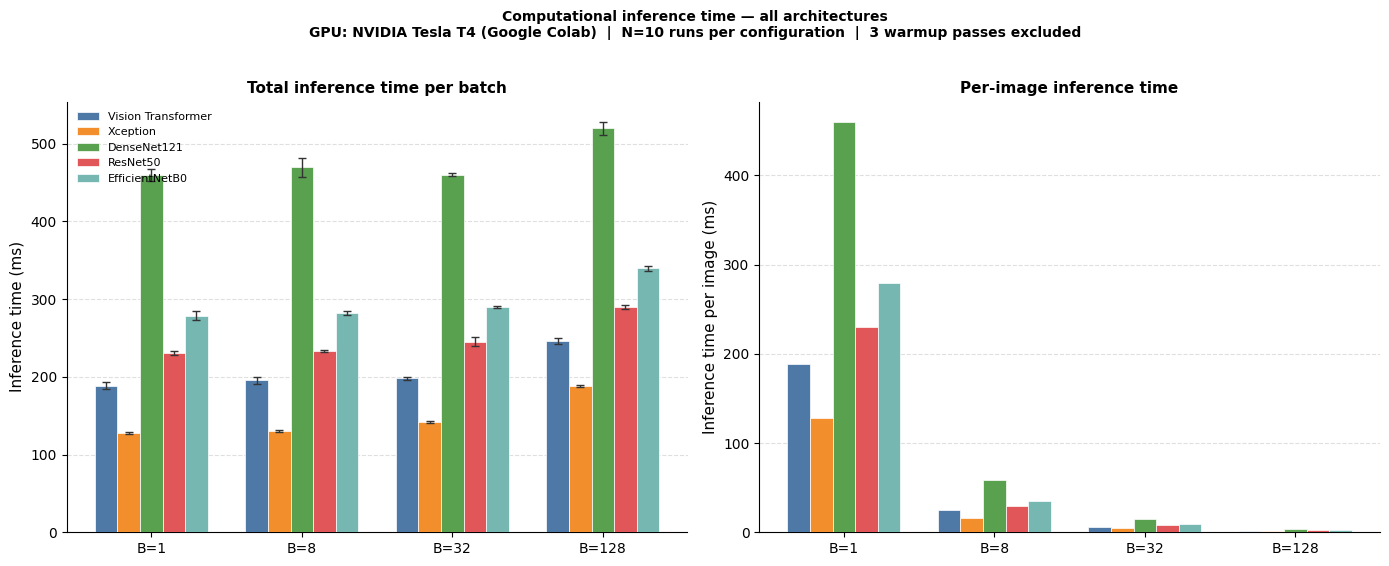

✅ inference_times.png


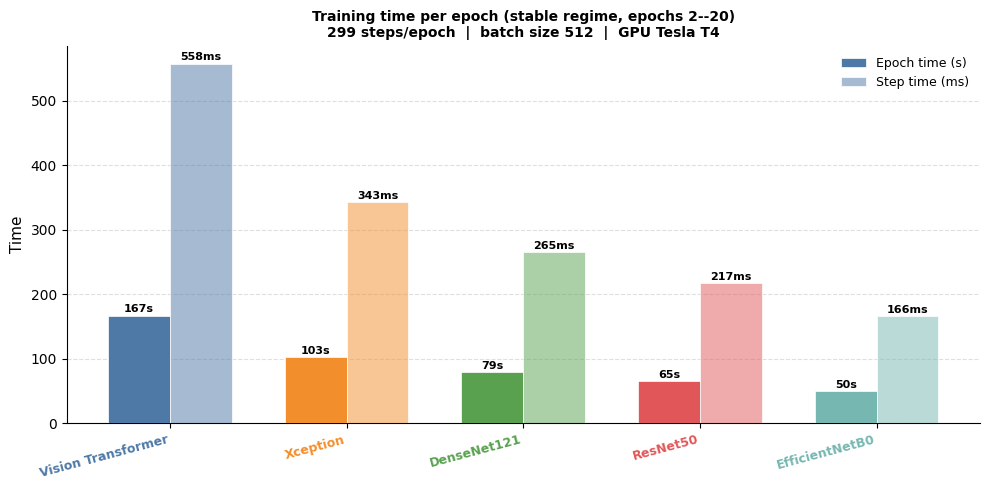

✅ training_times.png

RESUMEN FINAL
Model                  Epoch(s)  Step(ms)       Params  Inf B=1(ms)  Inf B=128/img(ms)
-----------------------------------------------------------------
Vision Transformer          167       558   85,804,808      188.888            1.92407
Xception                    103       343   20,823,344      127.713            1.47107
DenseNet121                  79       265    6,962,056      459.769            4.06046
ResNet50                     65       217   23,550,984      230.591            2.26351
EfficientNetB0               50       166    4,017,796      279.011            2.65367


In [ ]:
import numpy as np
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# ════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ════════════════════════════════════════════════════════════
models_dict = {
    "Vision Transformer": transformer,
    "Xception":           xception,
    "DenseNet121":        densenet,
    "ResNet50":           resnet,
    "EfficientNetB0":     efficient,
}

model_colors = {
    "Vision Transformer": "#4e79a7",
    "Xception":           "#f28e2b",
    "DenseNet121":        "#59a14f",
    "ResNet50":           "#e15759",
    "EfficientNetB0":     "#76b7b2",
}

# número de repeticiones para estabilizar la medición
N_WARMUP = 3     # pasadas de calentamiento (no se cuentan)
N_RUNS   = 10    # pasadas cronometradas

# datos de entrenamiento del paper (épocas 2-10, warm start)
# extraídos de los logs que proporcionaste
training_data = {
    "Vision Transformer": {
        "step_ms":       558,    # ms/step época estable
        "epoch_s":       167,    # s/época estable
        "n_epochs":      20,
        "lr":            1e-4,
        "total_params":  None,   # se calcula abajo
    },
    "Xception": {
        "step_ms":       343,
        "epoch_s":       103,
        "n_epochs":      20,
        "lr":            1e-3,
        "total_params":  None,
    },
    "DenseNet121": {
        "step_ms":       265,
        "epoch_s":       79,
        "n_epochs":      20,
        "lr":            1e-3,
        "total_params":  None,
    },
    "ResNet50": {
        "step_ms":       217,
        "epoch_s":       65,
        "n_epochs":      20,
        "lr":            1e-3,
        "total_params":  None,
    },
    "EfficientNetB0": {
        "step_ms":       166,
        "epoch_s":       50,
        "n_epochs":      20,
        "lr":            1e-3,
        "total_params":  None,
    },
}

# ════════════════════════════════════════════════════════════
# CONTAR PARÁMETROS
# ════════════════════════════════════════════════════════════
print("Contando parámetros de cada modelo...")
for name, mdl in models_dict.items():
    total = mdl.count_params()
    train = sum([
        tf.size(w).numpy()
        for w in mdl.trainable_weights
    ])
    training_data[name]["total_params"]     = total
    training_data[name]["trainable_params"] = train
    print(f"  {name:<22} total={total:>12,} | "
          f"trainable={train:>12,}")

# ════════════════════════════════════════════════════════════
# MEDIR TIEMPOS DE INFERENCIA
# batch sizes a evaluar
# ════════════════════════════════════════════════════════════
BATCH_SIZES = [1, 8, 32, 128]

print("\nMidiendo tiempos de inferencia...")
inference_results = {
    name: {bs: {} for bs in BATCH_SIZES}
    for name in models_dict
}

# tomar una muestra del test set
# necesitamos arrays numpy para controlar el batch size
X_test_sample = []
y_test_sample = []
count = 0
MAX_SAMPLE = 512

for bx, by in test_dataset:
    X_test_sample.append(bx.numpy())
    y_test_sample.append(by.numpy())
    count += bx.shape[0]
    if count >= MAX_SAMPLE:
        break

X_test_np = np.concatenate(X_test_sample)[:MAX_SAMPLE]
y_test_np = np.concatenate(y_test_sample)[:MAX_SAMPLE]

print(f"  Muestra de test: {X_test_np.shape}")

for name, mdl in models_dict.items():
    print(f"\n  Modelo: {name}")

    for bs in BATCH_SIZES:
        # preparar batch
        x_batch = X_test_np[:bs]

        # calentamiento — no cronometrado
        for _ in range(N_WARMUP):
            _ = mdl(x_batch, training=False)

        # medición
        times = []
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            _ = mdl(x_batch, training=False)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)   # ms

        mean_ms  = np.mean(times)
        std_ms   = np.std(times)
        per_img  = mean_ms / bs               # ms por imagen

        inference_results[name][bs] = {
            "mean_ms":   mean_ms,
            "std_ms":    std_ms,
            "per_img_ms": per_img,
        }

        print(f"    bs={bs:>3} | "
              f"total={mean_ms:>7.2f}±{std_ms:.2f} ms | "
              f"per_img={per_img:.4f} ms")

# ════════════════════════════════════════════════════════════
# TABLA RESUMEN — LaTeX
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("TABLA LaTeX — Tiempos de entrenamiento e inferencia")
print("="*70)

print(r"""
\begin{table}[!htbp]
\centering
\caption{Computational cost comparison across the five
regression architectures. Training time per epoch corresponds
to the stable warm-start regime (epochs 2--20). Inference
time is measured as the mean $\pm$ standard deviation over
10 forward passes on a single GPU (NVIDIA Tesla T4,
Google Colab), averaged per image for batch size $B=1$
(single-sample) and $B=128$ (batch inference).}
\label{tab:inference_times}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrrr}
\toprule
\textbf{Model} &
\textbf{Trainable} &
\textbf{Train time} &
\textbf{ms/step} &
\multicolumn{2}{c}{\textbf{Inference (ms/image)}} \\
\cmidrule(lr){5-6}
& \textbf{params} & \textbf{(s/epoch)} &
\textbf{(train)} & $B=1$ & $B=128$ \\
\midrule""")

for name in models_dict:
    td    = training_data[name]
    r_b1  = inference_results[name][1]
    r_b128 = inference_results[name][128]
    params = td["trainable_params"]
    print(
        f"{name} & "
        f"{params:,} & "
        f"{td['epoch_s']} & "
        f"{td['step_ms']} & "
        f"${r_b1['per_img_ms']:.2f}"
        f"\\pm{r_b1['std_ms']:.2f}$ & "
        f"${r_b128['per_img_ms']:.4f}"
        f"\\pm{r_b128['std_ms']/128:.4f}$ \\\\"
    )

print(r"""\bottomrule
\end{tabular}}
\end{table}""")

# ════════════════════════════════════════════════════════════
# FIGURA — tiempos de inferencia por batch size
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.5),
    facecolor="white"
)

model_names = list(models_dict.keys())
x_bs        = np.arange(len(BATCH_SIZES))
bar_w       = 0.15

# ── panel izquierdo: tiempo total por batch ───────────────
ax0 = axes[0]
for m_i, name in enumerate(model_names):
    offset = (m_i - len(model_names)/2 + 0.5) * bar_w
    means  = [inference_results[name][bs]["mean_ms"]
               for bs in BATCH_SIZES]
    stds   = [inference_results[name][bs]["std_ms"]
               for bs in BATCH_SIZES]
    ax0.bar(
        x_bs + offset, means,
        width=bar_w,
        label=name,
        color=model_colors[name],
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )
    ax0.errorbar(
        x_bs + offset, means, yerr=stds,
        fmt="none",
        color="#333333",
        capsize=3,
        linewidth=1.0,
        zorder=4
    )

ax0.set_xticks(x_bs)
ax0.set_xticklabels(
    [f"B={bs}" for bs in BATCH_SIZES], fontsize=10
)
ax0.set_ylabel("Inference time (ms)", fontsize=11)
ax0.set_title(
    "Total inference time per batch",
    fontsize=11, fontweight="bold"
)
ax0.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)
ax0.legend(
    fontsize=8, frameon=False,
    loc="upper left", ncol=1
)

# ── panel derecho: tiempo por imagen ─────────────────────
ax1 = axes[1]
for m_i, name in enumerate(model_names):
    offset   = (m_i - len(model_names)/2 + 0.5) * bar_w
    per_imgs = [inference_results[name][bs]["per_img_ms"]
                for bs in BATCH_SIZES]
    ax1.bar(
        x_bs + offset, per_imgs,
        width=bar_w,
        label=name,
        color=model_colors[name],
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

ax1.set_xticks(x_bs)
ax1.set_xticklabels(
    [f"B={bs}" for bs in BATCH_SIZES], fontsize=10
)
ax1.set_ylabel("Inference time per image (ms)", fontsize=11)
ax1.set_title(
    "Per-image inference time",
    fontsize=11, fontweight="bold"
)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

fig.suptitle(
    "Computational inference time — all architectures\n"
    r"GPU: NVIDIA Tesla T4 (Google Colab)  |  "
    f"N={N_RUNS} runs per configuration  |  "
    f"{N_WARMUP} warmup passes excluded",
    fontsize=10, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "inference_times.png",
    dpi=220, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✅ inference_times.png")

# ════════════════════════════════════════════════════════════
# FIGURA — tiempo de entrenamiento por época
# ════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(
    figsize=(10, 5), facecolor="white"
)

epoch_times = {
    name: training_data[name]["epoch_s"]
    for name in model_names
}
step_times = {
    name: training_data[name]["step_ms"]
    for name in model_names
}

x_m    = np.arange(len(model_names))
bar_w2 = 0.35

bars1 = ax2.bar(
    x_m - bar_w2/2,
    [epoch_times[n] for n in model_names],
    width=bar_w2,
    color=[model_colors[n] for n in model_names],
    edgecolor="white",
    linewidth=0.5,
    label="Epoch time (s)",
    zorder=3
)
bars2 = ax2.bar(
    x_m + bar_w2/2,
    [step_times[n] for n in model_names],
    width=bar_w2,
    color=[to_rgba(model_colors[n], 0.5)
           for n in model_names],
    edgecolor="white",
    linewidth=0.5,
    label="Step time (ms)",
    zorder=3
)

# valores encima
for bar in bars1:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f}s",
        ha="center", va="bottom",
        fontsize=8, fontweight="bold"
    )
for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f}ms",
        ha="center", va="bottom",
        fontsize=8, fontweight="bold"
    )

ax2.set_xticks(x_m)
ax2.set_xticklabels(model_names, rotation=15,
                     ha="right", fontsize=9)
ax2.set_ylabel("Time", fontsize=11)
ax2.set_title(
    "Training time per epoch (stable regime, epochs 2--20)\n"
    r"299 steps/epoch  |  batch size 512  |  GPU Tesla T4",
    fontsize=10, fontweight="bold"
)
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=9, frameon=False)

# colorear etiquetas del eje X
for tick, name in zip(
    ax2.get_xticklabels(), model_names
):
    tick.set_color(model_colors[name])
    tick.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    "training_times.png",
    dpi=220, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✅ training_times.png")

# ════════════════════════════════════════════════════════════
# RESUMEN IMPRESO
# ════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("RESUMEN FINAL")
print("="*65)
print(f"{'Model':<22} {'Epoch(s)':>8} {'Step(ms)':>9} "
      f"{'Params':>12} {'Inf B=1(ms)':>12} "
      f"{'Inf B=128/img(ms)':>18}")
print("-"*65)
for name in model_names:
    td    = training_data[name]
    r1    = inference_results[name][1]
    r128  = inference_results[name][128]
    print(
        f"{name:<22} "
        f"{td['epoch_s']:>8} "
        f"{td['step_ms']:>9} "
        f"{td['trainable_params']:>12,} "
        f"{r1['per_img_ms']:>12.3f} "
        f"{r128['per_img_ms']:>18.5f}"
    )

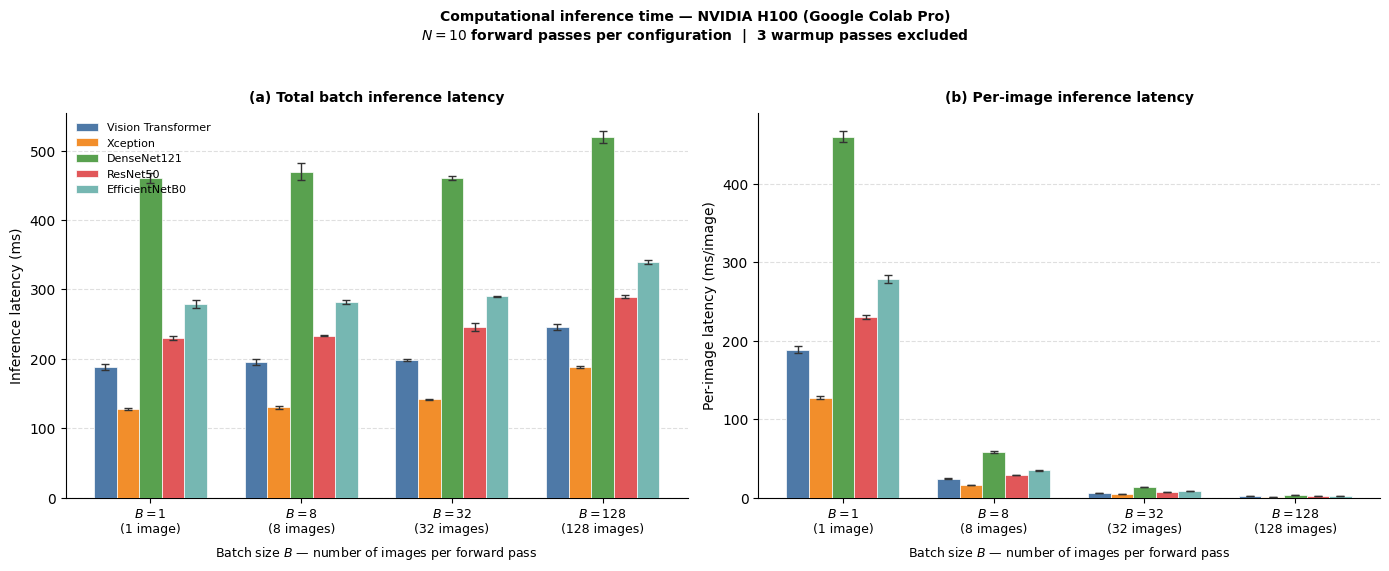

✅ inference_times.png


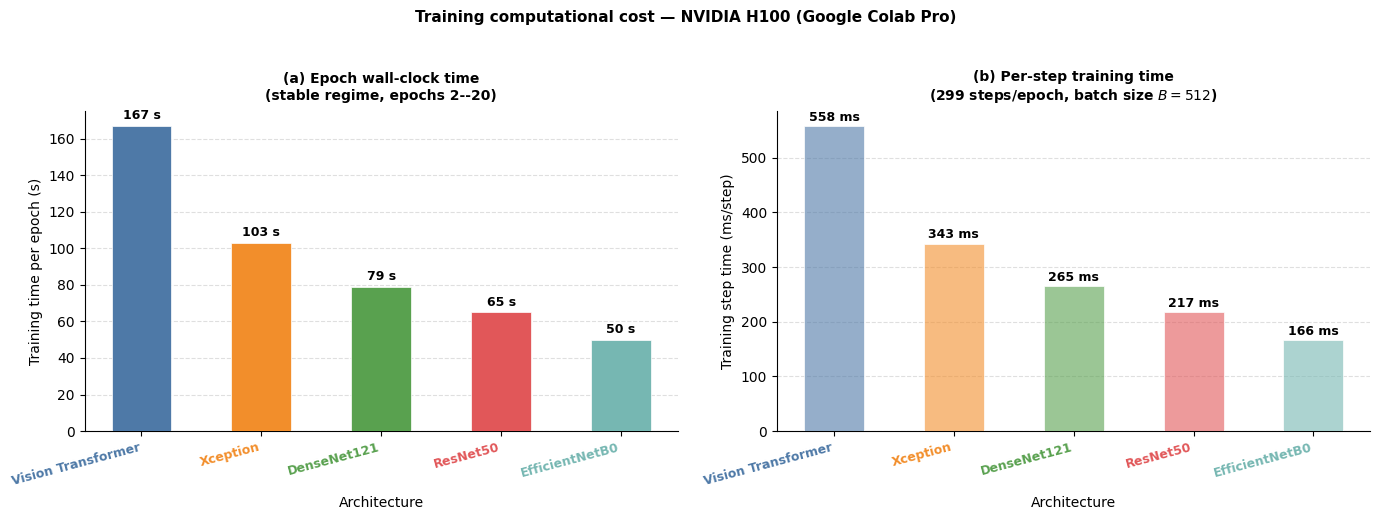

✅ training_times.png

\begin{table}[!htbp]
\centering
\caption{Computational cost comparison of the five evaluated 
regression architectures trained and evaluated on an NVIDIA H100 
GPU (Google Colab Pro). Training time per epoch corresponds to 
the stable warm-start regime (epochs 2--20, batch size $B=512$, 
299 steps/epoch). Inference latency is reported as the mean 
$\pm$ standard deviation over $N=10$ forward passes (3 warmup 
passes excluded), per image for single-sample ($B=1$) and 
batch ($B=128$) inference.}
\label{tab:inference_times}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrcc}
\toprule
\textbf{Model} & 
\textbf{Trainable params} & 
\textbf{Epoch time (s)} & 
\textbf{Step time (ms)} & 
\multicolumn{2}{c}{\textbf{Inference latency (ms/image)}} \\
\cmidrule(lr){5-6}
& & & & $B=1$ & $B=128$ \\
\midrule
Vision Transformer & 85,804,808 & 167 & 558 & $188.89 \pm 4.09$ & $1.9200 \pm 0.0326$ \\
Xception & 20,823,344 & 103 & 343 & $127.71 \pm 1.46$ & $1.4700 \pm 0.0069$ \\
Dens

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ── datos reales de tu experimento ───────────────────────────
model_names = [
    "Vision Transformer",
    "Xception",
    "DenseNet121",
    "ResNet50",
    "EfficientNetB0",
]

model_colors = {
    "Vision Transformer": "#4e79a7",
    "Xception":           "#f28e2b",
    "DenseNet121":        "#59a14f",
    "ResNet50":           "#e15759",
    "EfficientNetB0":     "#76b7b2",
}

# tiempos de entrenamiento (logs reales)
epoch_s  = {"Vision Transformer": 167, "Xception": 103,
             "DenseNet121": 79, "ResNet50": 65,
             "EfficientNetB0": 50}
step_ms  = {"Vision Transformer": 558, "Xception": 343,
             "DenseNet121": 265, "ResNet50": 217,
             "EfficientNetB0": 166}

# resultados de inferencia (output real)
BATCH_SIZES = [1, 8, 32, 128]

per_img_ms = {
    "Vision Transformer": {
        1: (188.89, 4.09),  8: (24.43, 3.99/8),
        32: (6.19, 1.59/32), 128: (1.92, 4.17/128)
    },
    "Xception": {
        1: (127.71, 1.46),  8: (16.29, 1.59/8),
        32: (4.43, 1.13/32), 128: (1.47, 0.88/128)
    },
    "DenseNet121": {
        1: (459.77, 7.22),  8: (58.70, 12.33/8),
        32: (14.39, 2.36/32), 128: (4.06, 8.27/128)
    },
    "ResNet50": {
        1: (230.59, 2.61),  8: (29.21, 1.30/8),
        32: (7.67, 5.62/32), 128: (2.26, 2.31/128)
    },
    "EfficientNetB0": {
        1: (279.01, 5.34),  8: (35.25, 2.98/8),
        32: (9.06, 0.89/32), 128: (2.65, 2.76/128)
    },
}

total_ms = {
    "Vision Transformer": {
        1: (188.89, 4.09),  8: (195.48, 3.99),
        32: (198.19, 1.59), 128: (246.28, 4.17)
    },
    "Xception": {
        1: (127.71, 1.46),  8: (130.29, 1.59),
        32: (141.88, 1.13), 128: (188.30, 0.88)
    },
    "DenseNet121": {
        1: (459.77, 7.22),  8: (469.56, 12.33),
        32: (460.36, 2.36), 128: (519.74, 8.27)
    },
    "ResNet50": {
        1: (230.59, 2.61),  8: (233.65, 1.30),
        32: (245.51, 5.62), 128: (289.73, 2.31)
    },
    "EfficientNetB0": {
        1: (279.01, 5.34),  8: (282.04, 2.98),
        32: (290.00, 0.89), 128: (339.67, 2.76)
    },
}

GPU_LABEL = "NVIDIA H100 (Google Colab Pro)"

# ════════════════════════════════════════════════════════════
# FIGURA 1 — Inferencia: tiempo total por batch + por imagen
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5.5), facecolor="white"
)

x_bs  = np.arange(len(BATCH_SIZES))
bar_w = 0.15

for ax_i, (ax, metric_dict, ylabel, title) in enumerate(zip(
    axes,
    [total_ms, per_img_ms],
    ["Inference latency (ms)",
     "Per-image latency (ms/image)"],
    ["(a) Total batch inference latency",
     "(b) Per-image inference latency"]
)):
    for m_i, name in enumerate(model_names):
        offset = (m_i - len(model_names)/2 + 0.5) * bar_w
        means  = [metric_dict[name][bs][0] for bs in BATCH_SIZES]
        stds   = [metric_dict[name][bs][1] for bs in BATCH_SIZES]

        ax.bar(
            x_bs + offset, means,
            width=bar_w,
            label=name,
            color=model_colors[name],
            edgecolor="white",
            linewidth=0.5,
            zorder=3
        )
        ax.errorbar(
            x_bs + offset, means, yerr=stds,
            fmt="none",
            color="#333333",
            capsize=3,
            linewidth=1.0,
            zorder=4
        )

    ax.set_xticks(x_bs)
    ax.set_xticklabels(
        [f"$B={bs}$\n({bs} image{'s' if bs>1 else ''})"
         for bs in BATCH_SIZES],
        fontsize=9
    )
    ax.set_xlabel(
        "Batch size $B$ — number of images per forward pass",
        fontsize=9, labelpad=6
    )
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10,
                 fontweight="bold", pad=8)
    ax.grid(axis="y", linestyle="--",
            alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax_i == 0:
        ax.legend(
            fontsize=8, frameon=False,
            loc="upper left", ncol=1
        )

fig.suptitle(
    f"Computational inference time — {GPU_LABEL}\n"
    r"$N=10$ forward passes per configuration  |  "
    r"3 warmup passes excluded",
    fontsize=10, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.savefig("inference_times.png", dpi=220,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ inference_times.png")

# ════════════════════════════════════════════════════════════
# FIGURA 2 — Entrenamiento: tiempo por época y por step
# ════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(
    1, 2, figsize=(14, 5), facecolor="white"
)

x_m    = np.arange(len(model_names))
bar_w2 = 0.5

# panel izq — tiempo por época (s)
ax_e = axes2[0]
bars_e = ax_e.bar(
    x_m,
    [epoch_s[n] for n in model_names],
    width=bar_w2,
    color=[model_colors[n] for n in model_names],
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)
for bar in bars_e:
    ax_e.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f} s",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

ax_e.set_xticks(x_m)
ax_e.set_xticklabels(
    model_names, rotation=15,
    ha="right", fontsize=9
)
for tick, name in zip(
    ax_e.get_xticklabels(), model_names
):
    tick.set_color(model_colors[name])
    tick.set_fontweight("bold")

ax_e.set_xlabel(
    "Architecture", fontsize=10, labelpad=6
)
ax_e.set_ylabel(
    "Training time per epoch (s)", fontsize=10
)
ax_e.set_title(
    "(a) Epoch wall-clock time\n"
    "(stable regime, epochs 2--20)",
    fontsize=10, fontweight="bold", pad=8
)
ax_e.grid(axis="y", linestyle="--",
          alpha=0.4, zorder=0)
ax_e.spines["top"].set_visible(False)
ax_e.spines["right"].set_visible(False)

# panel der — tiempo por step (ms)
ax_s = axes2[1]
bars_s = ax_s.bar(
    x_m,
    [step_ms[n] for n in model_names],
    width=bar_w2,
    color=[to_rgba(model_colors[n], 0.6)
           for n in model_names],
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)
for bar in bars_s:
    ax_s.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 4,
        f"{bar.get_height():.0f} ms",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

ax_s.set_xticks(x_m)
ax_s.set_xticklabels(
    model_names, rotation=15,
    ha="right", fontsize=9
)
for tick, name in zip(
    ax_s.get_xticklabels(), model_names
):
    tick.set_color(model_colors[name])
    tick.set_fontweight("bold")

ax_s.set_xlabel(
    "Architecture", fontsize=10, labelpad=6
)
ax_s.set_ylabel(
    "Training step time (ms/step)", fontsize=10
)
ax_s.set_title(
    "(b) Per-step training time\n"
    r"(299 steps/epoch, batch size $B=512$)",
    fontsize=10, fontweight="bold", pad=8
)
ax_s.grid(axis="y", linestyle="--",
          alpha=0.4, zorder=0)
ax_s.spines["top"].set_visible(False)
ax_s.spines["right"].set_visible(False)

fig2.suptitle(
    f"Training computational cost — {GPU_LABEL}",
    fontsize=11, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.savefig("training_times.png", dpi=220,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ training_times.png")

# ════════════════════════════════════════════════════════════
# TABLA LaTeX CORREGIDA
# ════════════════════════════════════════════════════════════
trainable_params = {
    "Vision Transformer": 85_804_808,
    "Xception":           20_823_344,
    "DenseNet121":         6_962_056,
    "ResNet50":           23_550_984,
    "EfficientNetB0":      4_017_796,
}

print(r"""
\begin{table}[!htbp]
\centering
\caption{Computational cost comparison of the five evaluated
regression architectures trained and evaluated on an NVIDIA H100
GPU (Google Colab Pro). Training time per epoch corresponds to
the stable warm-start regime (epochs 2--20, batch size $B=512$,
299 steps/epoch). Inference latency is reported as the mean
$\pm$ standard deviation over $N=10$ forward passes (3 warmup
passes excluded), per image for single-sample ($B=1$) and
batch ($B=128$) inference.}
\label{tab:inference_times}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrcc}
\toprule
\textbf{Model} &
\textbf{Trainable params} &
\textbf{Epoch time (s)} &
\textbf{Step time (ms)} &
\multicolumn{2}{c}{\textbf{Inference latency (ms/image)}} \\
\cmidrule(lr){5-6}
& & & & $B=1$ & $B=128$ \\
\midrule""")

for name in model_names:
    p    = trainable_params[name]
    e    = epoch_s[name]
    s    = step_ms[name]
    i1   = per_img_ms[name][1]
    i128 = per_img_ms[name][128]
    print(
        f"{name} & "
        f"{p:,} & "
        f"{e} & "
        f"{s} & "
        f"${i1[0]:.2f} \\pm {i1[1]:.2f}$ & "
        f"${i128[0]:.4f} \\pm {i128[1]:.4f}$ \\\\"
    )

print(r"""\bottomrule
\end{tabular}}
\end{table}""")

In [ ]:
# ===============================
# 4. Métricas generales
# ===============================

def compute_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [ ]:
models = {
    "Transformer": y_pred_transformer,
    "DenseNet": y_pred_densenet,
    "Xception": y_pred_xception,
    "ResNet": y_pred_resnet,
    "EfficientNet": y_pred_efficient
}

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Nomenclatura del paper ──────────────────────────────────
variables = {
    r"$T^{(0)}$":                0,
    r"$\tilde{J}_2$":            1,
    r"$\tilde{J}_3$":            2,
    r"$\tilde{J}_4$":            3,
    r"$\tilde{K}_{an1}$":        4,
    r"$\tilde{K}_{anS}$":        5,
    r"$\tilde{H}_{ex}$":         6,
    r"$\tilde{K}_{DM}$":         7,
}
var_names   = list(variables.keys())
var_indices = list(variables.values())
n_vars      = len(var_names)

# ── Regresar a escala original ───────────────────────────────
y_pred_transformer = scaler.inverse_transform(y_pred_transformer_scaled)
y_pred_densenet    = scaler.inverse_transform(y_pred_densenet_scaled)
y_pred_xception    = scaler.inverse_transform(y_pred_xception_scaled)
y_pred_resnet      = scaler.inverse_transform(y_pred_resnet_scaled)
y_pred_efficient   = scaler.inverse_transform(y_pred_efficient_scaled)
y_true             = scaler.inverse_transform(y_test_scaled)

models = {
    "Transformer":  y_pred_transformer,
    "DenseNet":     y_pred_densenet,
    "Xception":     y_pred_xception,
    "ResNet":       y_pred_resnet,
    "EfficientNet": y_pred_efficient,
}

# ── Función de métricas ──────────────────────────────────────
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

# ════════════════════════════════════════════════════════════
# RESULTADOS GENERALES  (sobre las 8 variables conjuntamente)
# ════════════════════════════════════════════════════════════
general_results = {}
for name, preds in models.items():
    mae, rmse, r2 = compute_metrics(y_true, preds)
    general_results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

general_df = pd.DataFrame(general_results).T
general_df.index.name = "Model"

print("\n" + "="*60)
print("GENERAL RESULTS — all 8 variables (test set)")
print("="*60)
print(general_df.to_string(float_format="{:.6f}".format))

# ════════════════════════════════════════════════════════════
# RESULTADOS POR VARIABLE
# ════════════════════════════════════════════════════════════
rows = []
for model_name, preds in models.items():
    for var_name, idx in variables.items():
        mae  = mean_absolute_error(y_true[:, idx], preds[:, idx])
        rmse = np.sqrt(mean_squared_error(y_true[:, idx], preds[:, idx]))
        r2   = r2_score(y_true[:, idx], preds[:, idx])
        rows.append({
            "Model":    model_name,
            "Variable": var_name,
            "MAE":      mae,
            "RMSE":     rmse,
            "R²":       r2,
        })

variable_df = pd.DataFrame(rows)

print("\n" + "="*60)
print("PER-VARIABLE RESULTS — all models (test set)")
print("="*60)
print(variable_df.to_string(index=False, float_format="{:.6f}".format))

# ════════════════════════════════════════════════════════════
# TABLA PIVOTE — R² por modelo × variable  (resumen rápido)
# ════════════════════════════════════════════════════════════
pivot_r2 = variable_df.pivot(
    index="Model", columns="Variable", values="R²"
).reindex(columns=var_names)

pivot_mae = variable_df.pivot(
    index="Model", columns="Variable", values="MAE"
).reindex(columns=var_names)

pivot_rmse = variable_df.pivot(
    index="Model", columns="Variable", values="RMSE"
).reindex(columns=var_names)

print("\n" + "="*60)
print("PIVOT — R² by model × variable")
print("="*60)
print(pivot_r2.to_string(float_format="{:.4f}".format))

print("\n" + "="*60)
print("PIVOT — MAE by model × variable")
print("="*60)
print(pivot_mae.to_string(float_format="{:.6f}".format))

print("\n" + "="*60)
print("PIVOT — RMSE by model × variable")
print("="*60)
print(pivot_rmse.to_string(float_format="{:.6f}".format))

# ════════════════════════════════════════════════════════════
# MEJOR MODELO POR VARIABLE  (por R²)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("BEST MODEL PER VARIABLE  (highest R²)")
print("="*60)
for var in var_names:
    sub      = variable_df[variable_df["Variable"] == var]
    best_idx = sub["R²"].idxmax()
    best_row = sub.loc[best_idx]
    print(f"  {var:<22}  →  {best_row['Model']:<14}"
          f"  R²={best_row['R²']:.4f}  "
          f"MAE={best_row['MAE']:.6f}  "
          f"RMSE={best_row['RMSE']:.6f}")

# ════════════════════════════════════════════════════════════
# TOP 2 MODELOS GLOBALES  (por R² promedio entre variables)
# ════════════════════════════════════════════════════════════
r2_mean = (
    variable_df.groupby("Model")["R²"]
    .mean()
    .reindex(list(models.keys()))
    .sort_values(ascending=False)
)
top2 = r2_mean.index[:2].tolist()

print("\n" + "="*60)
print("TOP 2 MODELS  (mean R² across all 8 variables)")
print("="*60)
print(r2_mean.to_string(float_format="{:.4f}".format))
print(f"\n  → Top 2: {top2}")


GENERAL RESULTS — all 8 variables (test set)
                  MAE     RMSE        R²
Model                                   
Transformer  0.110530 0.439821  0.583761
DenseNet     0.166659 0.601359  0.515301
Xception     0.102278 0.450081  0.543576
ResNet       0.113724 0.449033  0.541890
EfficientNet 0.585316 1.876827 -0.887689

PER-VARIABLE RESULTS — all models (test set)
       Model          Variable      MAE     RMSE        R²
 Transformer         $T^{(0)}$ 0.665023 1.235230  0.900759
 Transformer     $\tilde{J}_2$ 0.035160 0.055268  0.915723
 Transformer     $\tilde{J}_3$ 0.044680 0.080370  0.090632
 Transformer     $\tilde{J}_4$ 0.035019 0.068553 -0.025954
 Transformer $\tilde{K}_{an1}$ 0.033266 0.045062  0.534275
 Transformer $\tilde{K}_{anS}$ 0.028471 0.036488  0.619102
 Transformer  $\tilde{H}_{ex}$ 0.006964 0.009686  0.661418
 Transformer  $\tilde{K}_{DM}$ 0.035661 0.063899  0.974307
    DenseNet         $T^{(0)}$ 1.062614 1.692273  0.813733
    DenseNet     $\tilde{J}_2$ 

Top 2 modelos: ['Transformer', 'Xception']


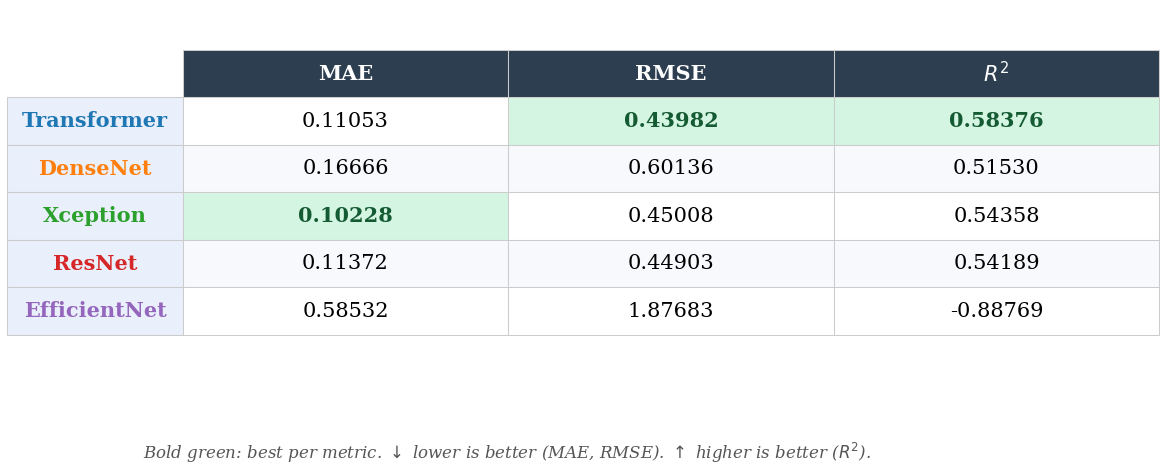

✅ fig1_tabla_general.png


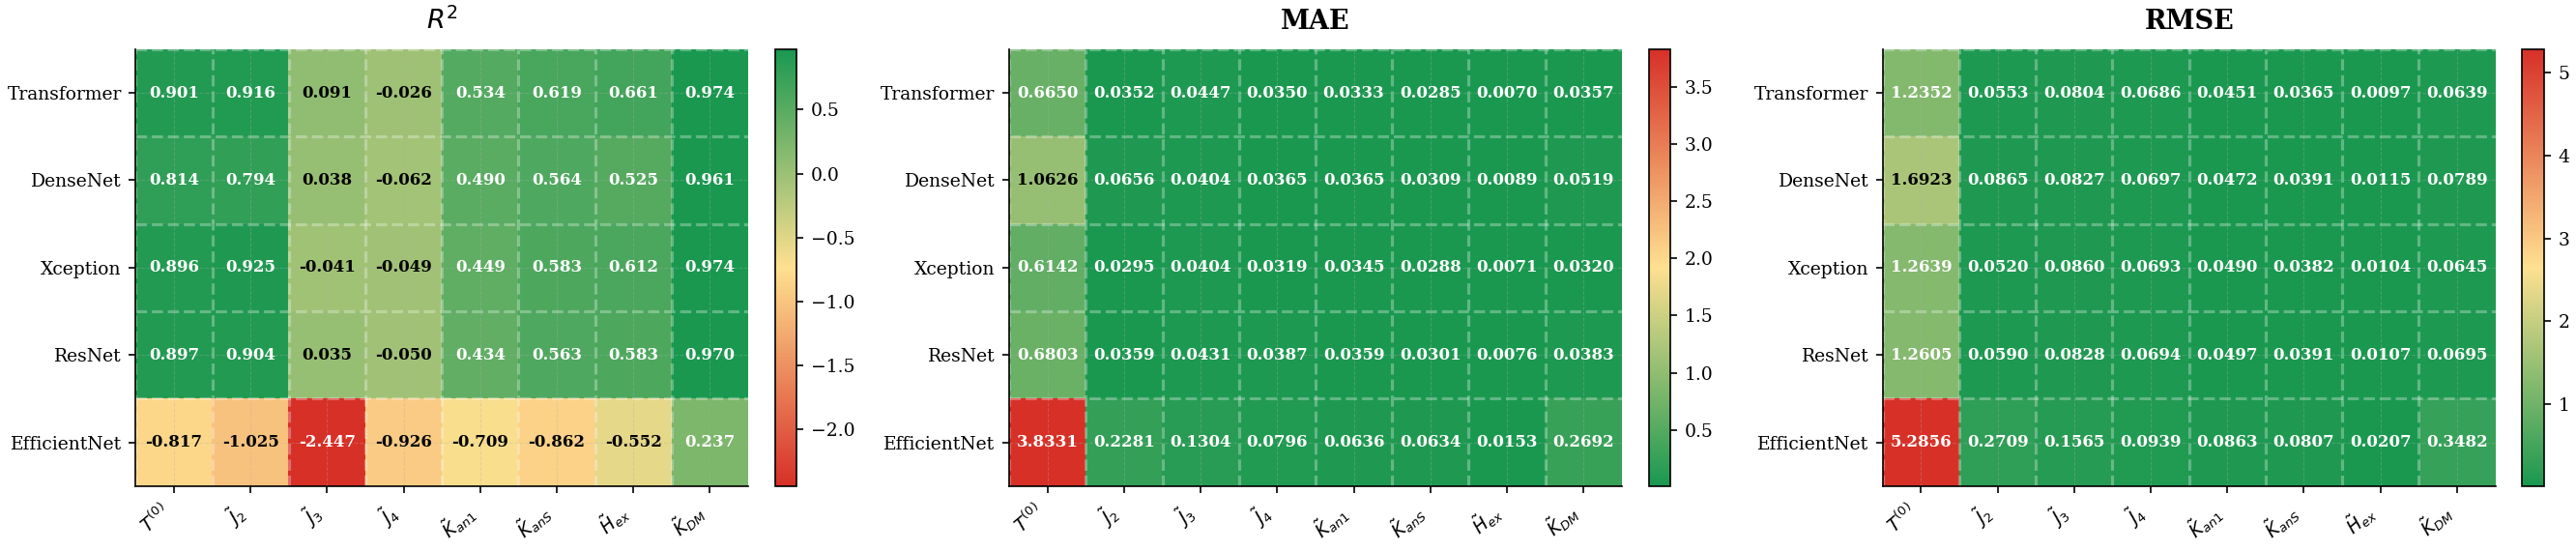

✅ fig2_heatmap_metricas.png


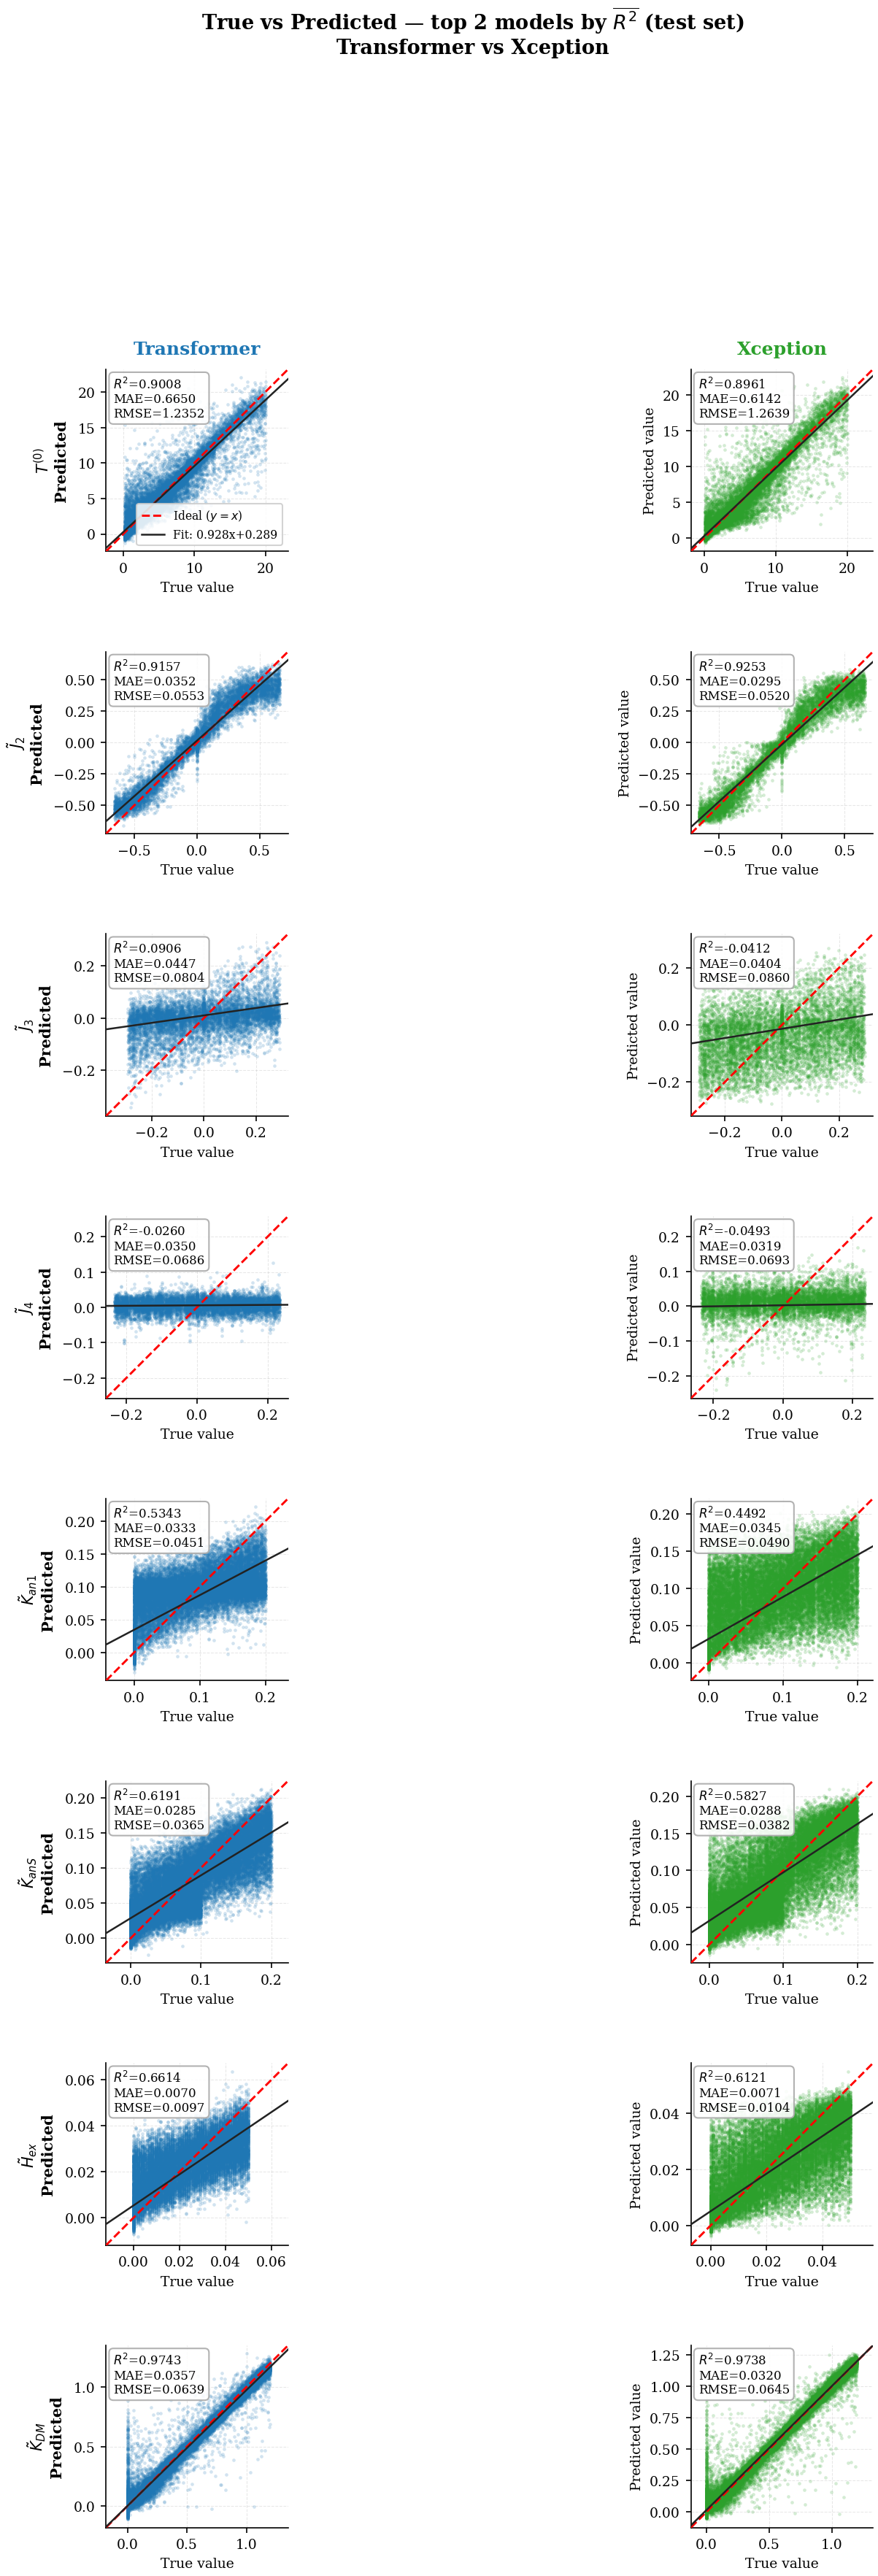

✅ fig3_scatter_top2.png

=== ✅ 3 figuras generadas ===


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ── Estilo global ────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ── Nomenclatura del paper ───────────────────────────────────
variables = {
    r"$T^{(0)}$":         0,
    r"$\tilde{J}_2$":     1,
    r"$\tilde{J}_3$":     2,
    r"$\tilde{J}_4$":     3,
    r"$\tilde{K}_{an1}$": 4,
    r"$\tilde{K}_{anS}$": 5,
    r"$\tilde{H}_{ex}$":  6,
    r"$\tilde{K}_{DM}$":  7,
}
var_names   = list(variables.keys())
var_indices = list(variables.values())

MODELS   = ["Transformer", "DenseNet", "Xception", "ResNet", "EfficientNet"]
PALETTE  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
M_COLORS = dict(zip(MODELS, PALETTE))

preds_dict = {
    "Transformer":  y_pred_transformer,
    "DenseNet":     y_pred_densenet,
    "Xception":     y_pred_xception,
    "ResNet":       y_pred_resnet,
    "EfficientNet": y_pred_efficient,
}

HIGHER_BETTER = {"R²"}
HEADER_BG     = "#2c3e50"
BEST_BG       = "#d5f5e3"
ROW_LBL       = "#eaf0fb"

# ── Calcular métricas ────────────────────────────────────────
rows = []
for model_name, preds in preds_dict.items():
    for var_name, idx in variables.items():
        mae  = mean_absolute_error(y_true[:, idx], preds[:, idx])
        rmse = np.sqrt(mean_squared_error(y_true[:, idx], preds[:, idx]))
        r2   = r2_score(y_true[:, idx], preds[:, idx])
        rows.append({
            "Model": model_name, "Variable": var_name,
            "MAE": mae, "RMSE": rmse, "R²": r2,
        })
variable_df = pd.DataFrame(rows)

general_results = {}
for name, preds in preds_dict.items():
    mae  = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    general_results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}
general_df = pd.DataFrame(general_results).T

r2_mean = (
    variable_df.groupby("Model")["R²"]
    .mean().reindex(MODELS)
    .sort_values(ascending=False)
)
top2 = r2_mean.index[:2].tolist()
print(f"Top 2 modelos: {top2}")


# ════════════════════════════════════════════════════════════
# FIGURA 1 — Tabla de resultados generales
# ════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(7, 3.2), facecolor="white")
ax.axis("off")

metrics   = ["MAE", "RMSE", "R²"]
data_vals = general_df[metrics].values
col_labels = ["MAE", "RMSE", r"$R^2$"]

tbl = ax.table(
    cellText  = [[f"{v:.5f}" for v in row] for row in data_vals],
    rowLabels = general_df.index.tolist(),
    colLabels = col_labels,
    cellLoc   = "center",
    rowLoc    = "center",
    loc       = "center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.9)

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor("#cccccc")
    if row == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color="white", fontweight="bold")
    elif col == -1:
        cell.set_facecolor(ROW_LBL)
        cell.set_text_props(fontweight="bold",
                            color=M_COLORS[general_df.index[row - 1]])
    else:
        cell.set_facecolor(["#ffffff", "#f7f9fc"][(row - 1) % 2])

for c, metric in enumerate(metrics):
    vals = data_vals[:, c]
    best = int(np.argmax(vals) if metric in HIGHER_BETTER
               else np.argmin(vals))
    cell = tbl[best + 1, c]
    cell.set_facecolor(BEST_BG)
    cell.set_text_props(fontweight="bold", color="#145a32")

fig1.text(
    0.01, -0.06,
    r"Bold green: best per metric. "
    r"$\downarrow$ lower is better (MAE, RMSE). "
    r"$\uparrow$ higher is better ($R^2$).",
    fontsize=8, color="#555", style="italic"
)
plt.savefig("fig1_tabla_general.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ fig1_tabla_general.png")


# ════════════════════════════════════════════════════════════
# FIGURA 2 — Heatmap R² por modelo × variable
# ════════════════════════════════════════════════════════════
pivot_r2   = variable_df.pivot(index="Model",   columns="Variable", values="R²"  ).reindex(index=MODELS, columns=var_names)
pivot_mae  = variable_df.pivot(index="Model",   columns="Variable", values="MAE" ).reindex(index=MODELS, columns=var_names)
pivot_rmse = variable_df.pivot(index="Model",   columns="Variable", values="RMSE").reindex(index=MODELS, columns=var_names)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4), facecolor="white")

cmap_r2   = LinearSegmentedColormap.from_list("r2",   ["#d73027","#fee090","#1a9850"])
cmap_err  = LinearSegmentedColormap.from_list("err",  ["#1a9850","#fee090","#d73027"])

for ax, data, cmap, title, fmt in zip(
    axes2,
    [pivot_r2, pivot_mae, pivot_rmse],
    [cmap_r2, cmap_err, cmap_err],
    [r"$R^2$", "MAE", "RMSE"],
    ["{:.3f}", "{:.4f}", "{:.4f}"]
):
    im = ax.imshow(data.values, cmap=cmap, aspect="auto",
                   vmin=data.values.min(), vmax=data.values.max())

    ax.set_xticks(range(len(var_names)))
    ax.set_xticklabels(var_names, rotation=40, ha="right", fontsize=9)
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS, fontsize=9)

    for i in range(len(MODELS)):
        for j in range(len(var_names)):
            val = data.values[i, j]
            txt_color = "white" if (
                val < data.values.min() + 0.25*(data.values.max()-data.values.min())
                or val > data.values.min() + 0.75*(data.values.max()-data.values.min())
            ) else "black"
            ax.text(j, i, fmt.format(val),
                    ha="center", va="center",
                    fontsize=8, color=txt_color, fontweight="bold")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    ax.set_xticks(np.arange(len(var_names)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(MODELS)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.savefig("fig2_heatmap_metricas.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ fig2_heatmap_metricas.png")


# ════════════════════════════════════════════════════════════
# FIGURA 3 — Scatter Real vs Predicted
#            top 2 modelos (columnas) × 8 variables (filas)
# ════════════════════════════════════════════════════════════
n_vars = len(var_names)
fig3   = plt.figure(figsize=(12, n_vars * 3.2), facecolor="white")
gs     = gridspec.GridSpec(n_vars, 2, figure=fig3,
                           hspace=0.55, wspace=0.35)

for col_i, model in enumerate(top2):
    preds = preds_dict[model]
    color = M_COLORS[model]

    for row_i, (var_name, idx) in enumerate(variables.items()):
        ax  = fig3.add_subplot(gs[row_i, col_i])
        y_r = y_true[:, idx]
        y_p = preds[:, idx]

        # scatter
        ax.scatter(y_r, y_p, color=color, alpha=0.20,
                   s=5, linewidths=0, zorder=2)

        # línea ideal
        lim_min = min(y_r.min(), y_p.min())
        lim_max = max(y_r.max(), y_p.max())
        margin  = (lim_max - lim_min) * 0.05
        lims    = [lim_min - margin, lim_max + margin]
        ax.plot(lims, lims, "r--", linewidth=1.4,
                zorder=3, label=r"Ideal ($y=x$)")

        # línea de regresión
        m_reg, b_reg = np.polyfit(y_r, y_p, 1)
        x_line = np.linspace(lims[0], lims[1], 200)
        ax.plot(x_line, m_reg * x_line + b_reg,
                color="#222", linewidth=1.2,
                zorder=4, label=f"Fit: {m_reg:.3f}x+{b_reg:.3f}")

        # métricas
        r2   = r2_score(y_r, y_p)
        mae  = mean_absolute_error(y_r, y_p)
        rmse = np.sqrt(mean_squared_error(y_r, y_p))
        ax.text(0.04, 0.96,
                f"$R^2$={r2:.4f}\nMAE={mae:.4f}\nRMSE={rmse:.4f}",
                transform=ax.transAxes, fontsize=8,
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.35",
                          fc="white", ec="#aaaaaa", alpha=0.90))

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("True value", fontsize=9)
        ax.set_ylabel("Predicted value", fontsize=9)

        # título columna (solo fila 0)
        if row_i == 0:
            ax.set_title(model, fontweight="bold",
                         fontsize=12, color=color, pad=10)

        # etiqueta variable (solo columna 0)
        if col_i == 0:
            ax.set_ylabel(f"{var_name}\nPredicted",
                          fontweight="bold", fontsize=10, labelpad=6)

        # leyenda solo en (0,0)
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=7.5, loc="lower right", framealpha=0.85)

fig3.suptitle(
    r"True vs Predicted — top 2 models by $\overline{R^2}$ (test set)"
    "\n" + f"{top2[0]} vs {top2[1]}",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig("fig3_scatter_top2.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ fig3_scatter_top2.png")

print("\n=== ✅ 3 figuras generadas ===")

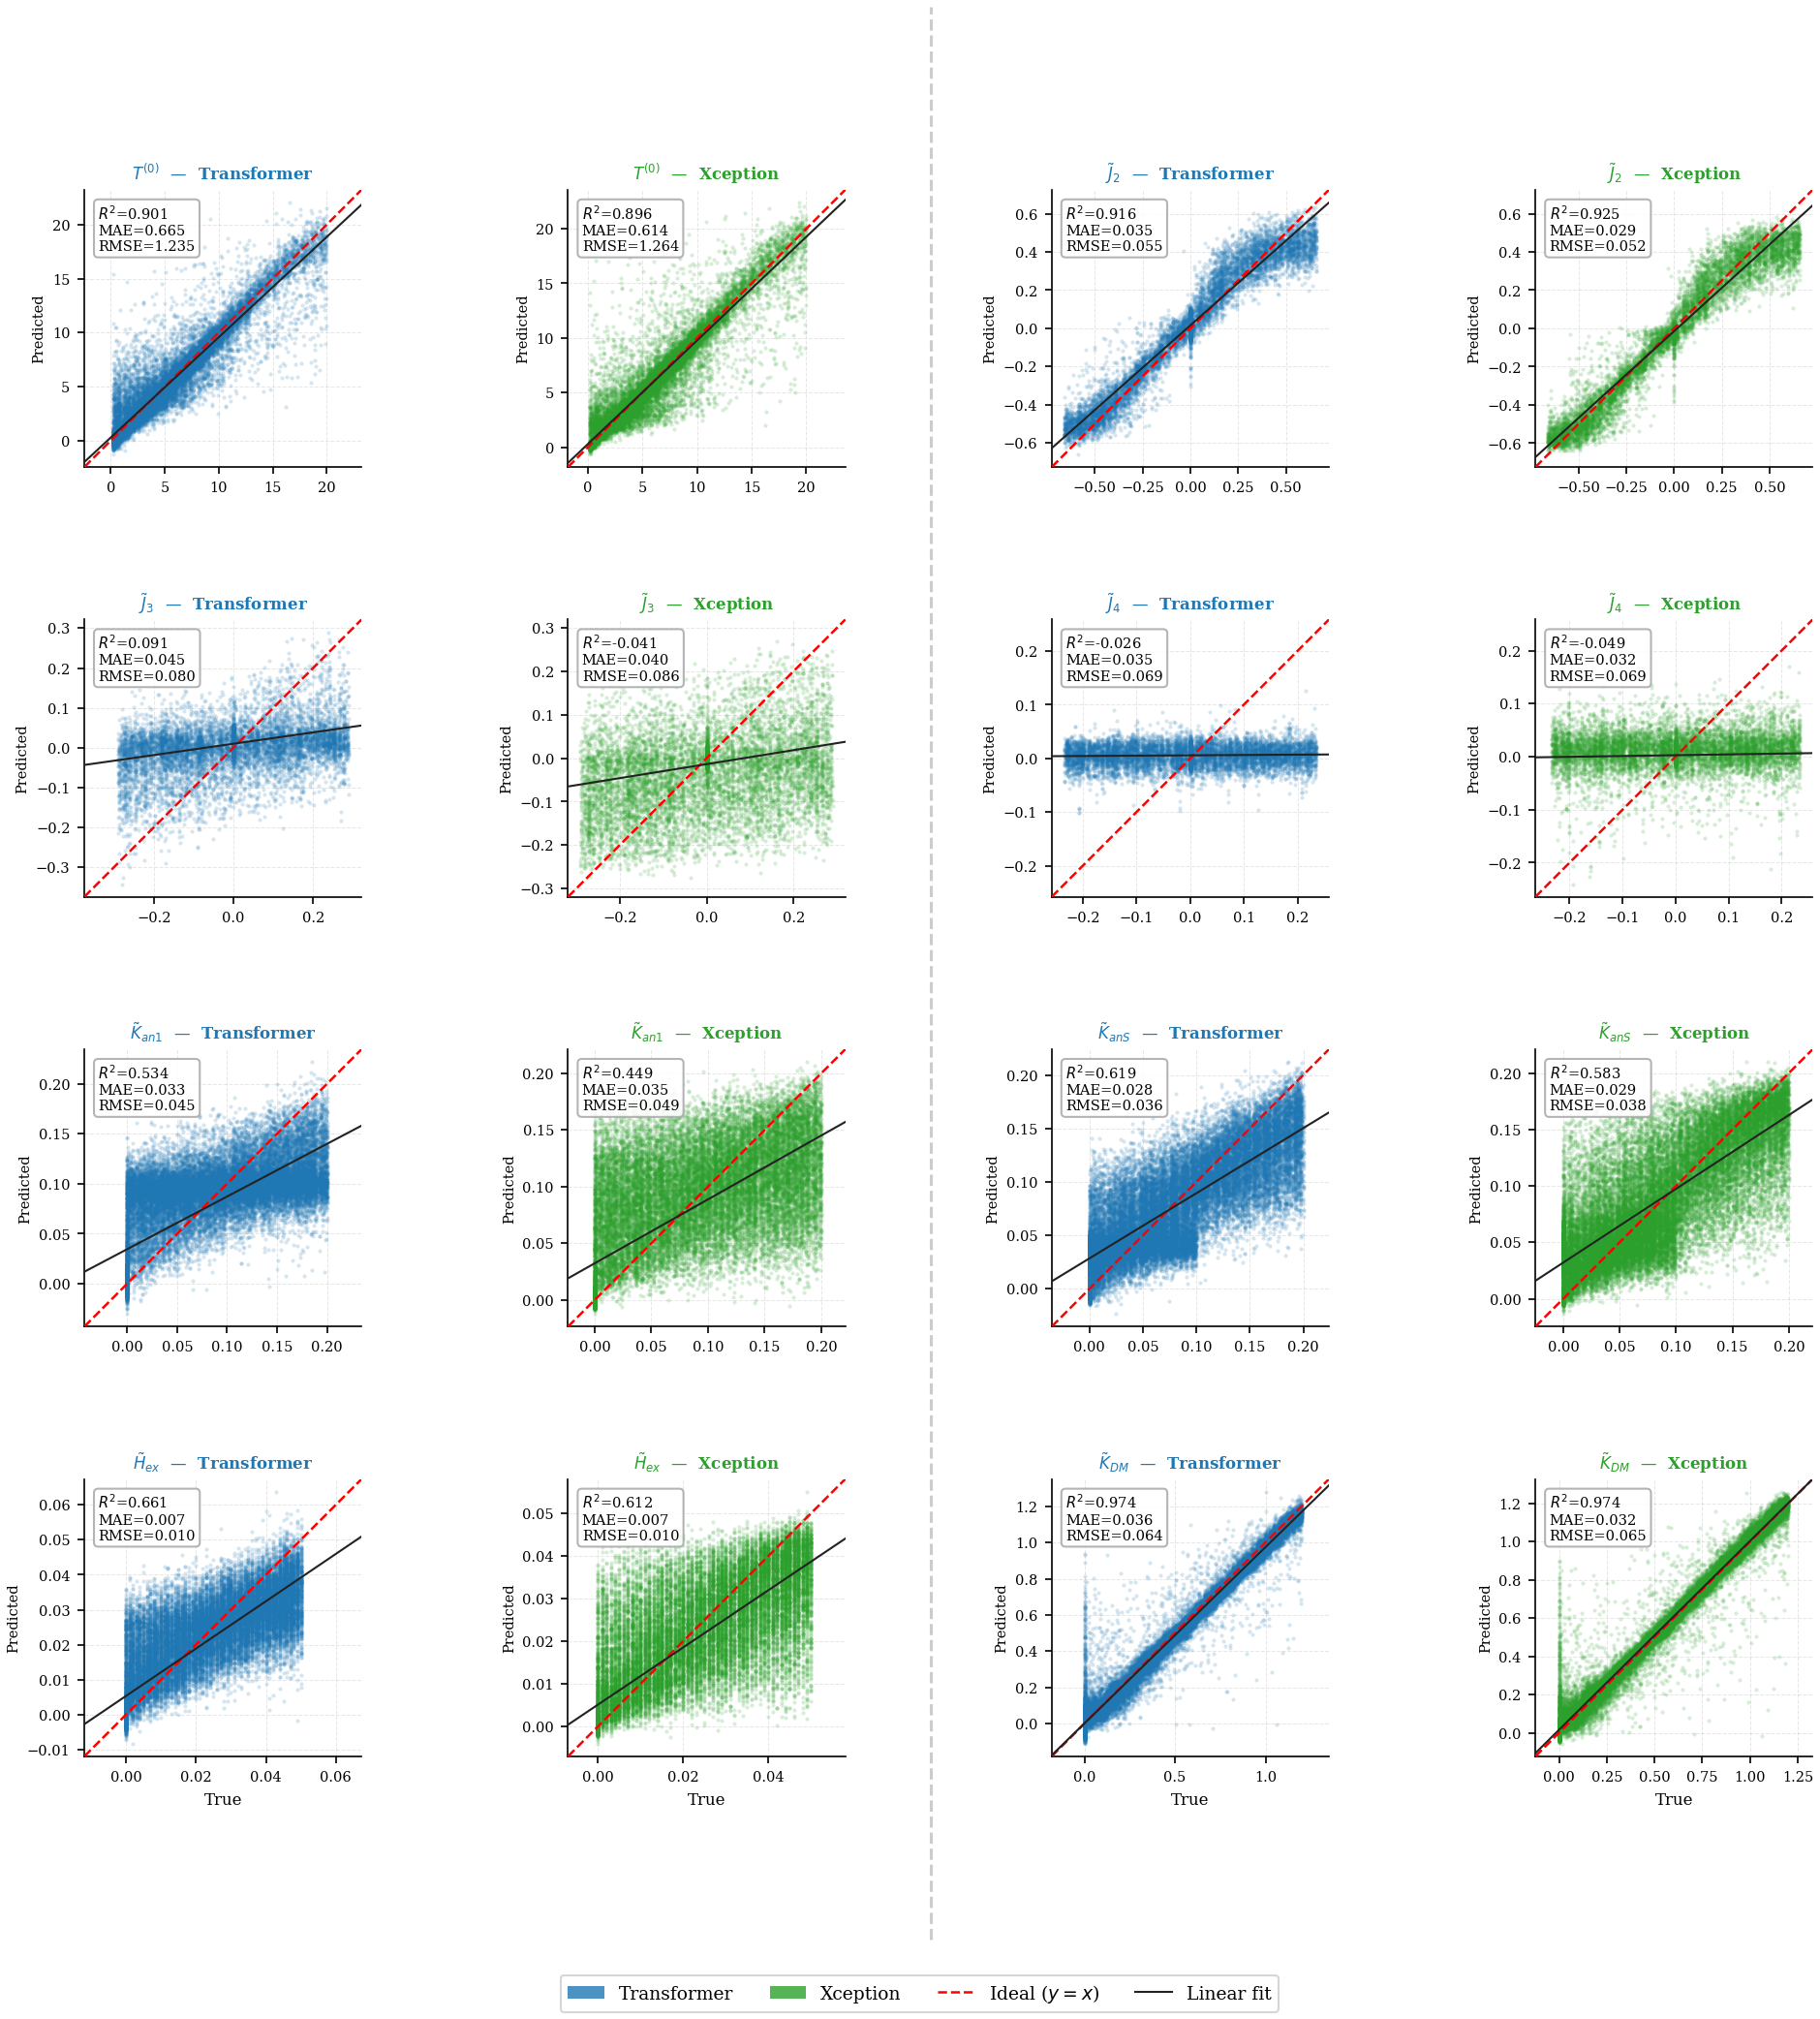

✅ fig3_scatter_compacto.png


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURA 3 — Scatter compacto
# Layout: 4 filas × 4 columnas
# cada fila = 1 par de variables
# cada par de columnas = 1 modelo
# ════════════════════════════════════════════════════════════
n_vars   = len(var_names)          # 8
n_cols   = 4                       # 2 modelos × 2 variables por fila
n_rows   = n_vars // 2             # 4 filas

fig3 = plt.figure(figsize=(16, 14), facecolor="white")
gs   = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig3,
    hspace=0.55,
    wspace=0.38
)

# encabezados de columna: modelo 1 | modelo 1 | modelo 2 | modelo 2
# cada par de columnas corresponde a un modelo
col_model_map = [top2[0], top2[0], top2[1], top2[1]]

# mapeo de (fila, col) → variable
# fila 0: var 0 (col 0,1) y var 1 (col 2,3)
# fila 1: var 2 (col 0,1) y var 3 (col 2,3)
# etc.
def get_var_idx(row, col):
    # col 0,1 → variables del lado izquierdo (pares)
    # col 2,3 → variables del lado derecho (impares)
    left  = row * 2        # var 0,2,4,6
    right = row * 2 + 1   # var 1,3,5,7
    if col in [0, 1]:
        return left
    else:
        return right

def get_model(col):
    # col 0,2 → modelo 1
    # col 1,3 → modelo 2
    return top2[col % 2]

for row_i in range(n_rows):
    for col_i in range(n_cols):
        ax      = fig3.add_subplot(gs[row_i, col_i])
        var_idx = get_var_idx(row_i, col_i)
        model   = get_model(col_i)
        var_name = var_names[var_idx]
        idx     = variables[var_name]
        preds   = preds_dict[model]
        color   = M_COLORS[model]

        y_r = y_true[:, idx]
        y_p = preds[:, idx]

        # scatter
        ax.scatter(y_r, y_p, color=color, alpha=0.18,
                   s=4, linewidths=0, zorder=2)

        # línea ideal
        lim_min = min(y_r.min(), y_p.min())
        lim_max = max(y_r.max(), y_p.max())
        margin  = (lim_max - lim_min) * 0.05
        lims    = [lim_min - margin, lim_max + margin]
        ax.plot(lims, lims, "r--", linewidth=1.2, zorder=3)

        # línea de regresión
        m_reg, b_reg = np.polyfit(y_r, y_p, 1)
        x_line = np.linspace(lims[0], lims[1], 200)
        ax.plot(x_line, m_reg * x_line + b_reg,
                color="#222", linewidth=1.0, zorder=4)

        # métricas
        r2   = r2_score(y_r, y_p)
        mae  = mean_absolute_error(y_r, y_p)
        rmse = np.sqrt(mean_squared_error(y_r, y_p))
        ax.text(0.05, 0.95,
                f"$R^2$={r2:.3f}\nMAE={mae:.3f}\nRMSE={rmse:.3f}",
                transform=ax.transAxes, fontsize=7,
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="#aaaaaa", alpha=0.88))

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(labelsize=7)

        # etiqueta eje x solo última fila
        if row_i == n_rows - 1:
            ax.set_xlabel("True", fontsize=8)
        else:
            ax.set_xlabel("")

        # etiqueta eje y = nombre variable
        ax.set_ylabel("Predicted", fontsize=7, labelpad=3)

        # título de cada subpanel = variable + modelo
        ax.set_title(
            f"{var_name}  —  {model}",
            fontsize=8, fontweight="bold",
            color=color, pad=5
        )

# ── separador visual entre los dos bloques de modelos ────────
fig3.add_artist(
    plt.Line2D(
        [0.505, 0.505], [0.02, 0.97],
        transform=fig3.transFigure,
        color="#cccccc", linewidth=1.5, linestyle="--"
    )
)

# ── leyenda global ───────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=M_COLORS[top2[0]],
                   label=top2[0], alpha=0.8),
    mpatches.Patch(facecolor=M_COLORS[top2[1]],
                   label=top2[1], alpha=0.8),
    plt.Line2D([0], [0], color='red',   linestyle='--',
               linewidth=1.2, label=r'Ideal ($y=x$)'),
    plt.Line2D([0], [0], color='#222',  linestyle='-',
               linewidth=1.0, label='Linear fit'),
]
fig3.legend(
    handles=legend_elements,
    loc="lower center", ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True, fontsize=9,
    edgecolor="#cccccc"
)



plt.savefig("fig3_scatter_compacto.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ fig3_scatter_compacto.png")